In [2]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom

In [3]:
data=np.load(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\doppler_sigma_vel_all.npz')
doppler_vel_all = data['doppler_vel_all']
sigma_vel_all = data['sigma_vel_all']

进行谱线展宽的修正，去掉热展宽和仪器展宽  
以及需要注意sigma用的是正态分布的，差了个根号二  
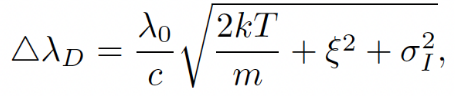  
这个2kT/m，是因为用的1/e宽度导致的，实际热致宽没有2，并且m应该是Si的质量  
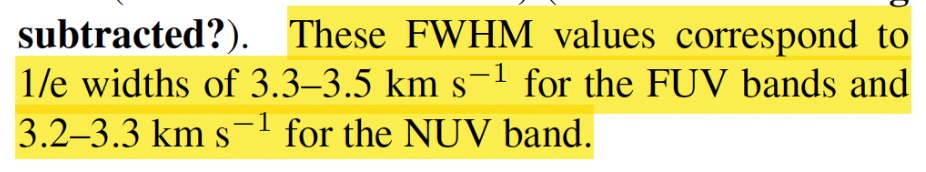  
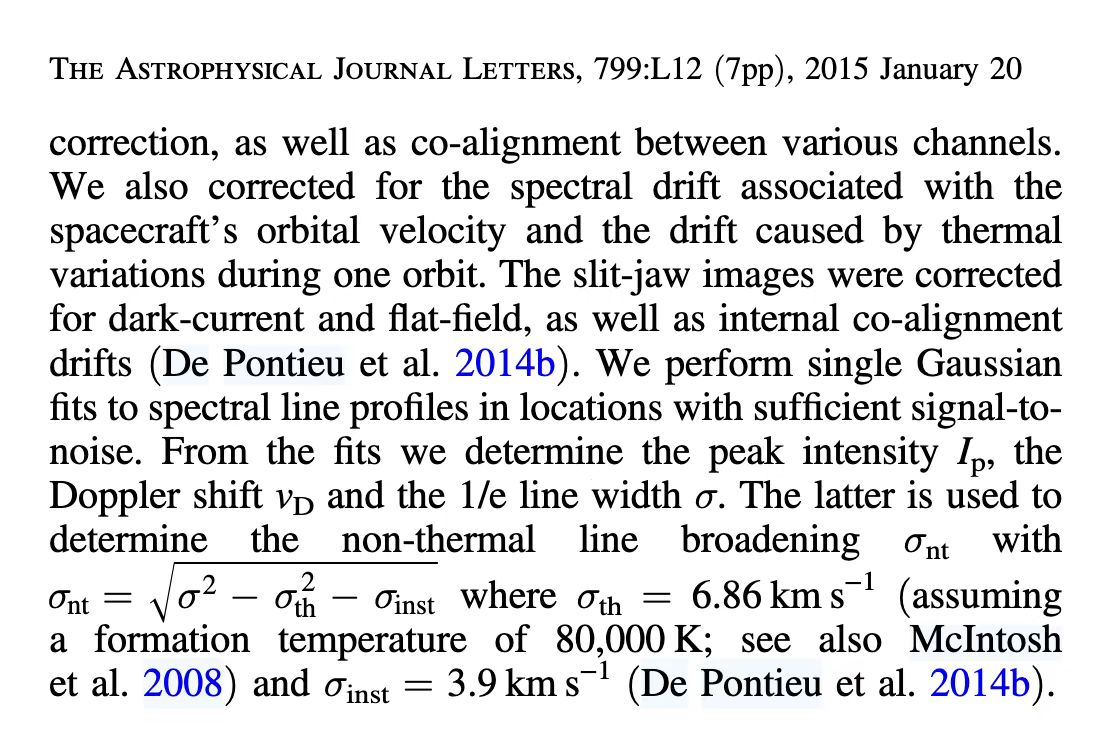  
122-200是FUV 300-400是NUV  1402.77应该是FUV  
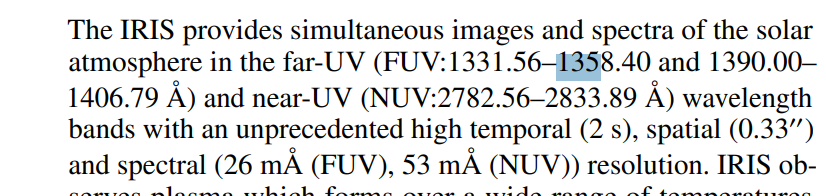  
，来自文章。<font color=red>这里的3.9除$\sqrt{2}$就是$\sigma$了</font>  
http://dx.doi.org/10.1088/2041-8205/799/1/L12 这是文章链接  
需要注意的是，我之前求出来的是幂指数分母为2sigma^2里面的sigma，这个3.9是1/e高度时的宽度，也就是$W_{1/2}=2\sqrt{2}\sigma$  
不要管上面那个3.3-3.5的了

In [12]:
#不管了，就用1/e的线宽吧，我算出来的这个热致线宽对应他的6.86的，我的是12.85，差的还是挺多的用人家的吧
sigma_I=3.9/(np.sqrt(2))
#之后算热致展宽,这个已经是平方项了
sigma_thermal=1.38*10**(-23)*10**(4.9)/(28.09*1.67*10**(-27))/1e6
threshold=np.sqrt(sigma_I**2+sigma_thermal)
print(threshold)

5.5652875937076205


In [1]:
import amrvac_pytools

In [13]:
#这里用的是SiIV 1402.77这条谱线
#FWHM/1402.77*C=3.9KM/S
#FWHM=sqrt(ln(2))*sigma
sigma_I=3.9/(np.sqrt(2))
#之后算热致展宽,这个已经是平方项了
sigma_thermal=1.38*10**(-23)*10**(4.9)/(28.04*1.67*10**(-27))/1e6
threshold=np.sqrt(sigma_I**2+sigma_thermal)
sigma_vel_nonth=np.zeros((12,110))
for i in range(12):
    for j in range(110):
        if sigma_vel_all[i,j]*np.sqrt(2)>threshold:
            sigma_vel_nonth[i,j]=np.sqrt(sigma_vel_all[i,j]**2*2-threshold**2)
        else:
            sigma_vel_nonth[i,j]=0
np.savez(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\doppler_sigma_vel_nonth.npz',
         doppler_vel_all=doppler_vel_all,sigma_vel_nonth=sigma_vel_nonth)
#这里的sigma_vel_nonth就是非热展宽

In [5]:
data=np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\doppler_sigma_vel_nonth.npz')
doppler_vel=data['doppler_vel_all']
sigma_vel=data['sigma_vel_nonth']

In [4]:
all_sji_image=readsav(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\all_sji_image.sav')['matrix_struct']
file_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')

In [15]:
from datetime import datetime, timedelta

# 定义起始时间
start_time = datetime.fromisoformat('2024-06-18T16:31:42')
# 定义每次增加的时间间隔
interval = timedelta(seconds=20.8583)

# 生成时间序列
time_sequence = []
for i in range(990):
    current_time = start_time + i * interval
    # 格式化时间为只显示到秒
    time_str = current_time.strftime('%Y-%m-%d T%H:%M:%S')
    time_sequence.append(time_str)

In [ ]:
#生成多普勒速度（单高斯）和非热展宽的图
for cnt in range(12):
	i=797+2*cnt
	fig,down_ax=plt.subplots(figsize=(5.5,5))
	fig_data=all_sji_image[i][0][330:,:]
	down_ax.imshow(fig_data,cmap='irissji1400',vmin=0,vmax=20,origin='lower',
	extent=[0,422*0.166,0,330*0.166])
	down_ax.set_xlabel('X [arcsec]')
	down_ax.set_ylabel('Y [arcsec]')
	down_ax.set_aspect('auto')  # 或 'box' 而不是 'equal'
	right_ax = down_ax.twinx()
	right_ax.set_ylim(110, 220)
	right_ax.set_ylabel('pixel along the slit')
	#创建第二根x轴
	up_ax=down_ax.twiny()
	#转化单位到角秒
	y_vals=np.linspace(0,330*0.166,110)
	up_ax.plot(doppler_vel_all[cnt,:],y_vals,color='cyan',linewidth=0.8,label='doppler velocity')
	up_ax.plot(sigma_vel_nonth[cnt,:],y_vals,color='orange',linewidth=0.8,label='velocity dispersion')
	up_ax.set_xlim(-210,190)
	wave_x=np.arange(1398.28,1398.28+164*0.0508,0.0508)
	x=wave_x[70:110]

	up_ax.set_xlabel('Velocity [km/s]')
	up_ax.set_title(time_sequence[i])
	up_ax.legend()
	up_ax.minorticks_on()
	up_ax.axvline(0,color='blue',linestyle='--')
	fig.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\fig_with_vel\\'+str(i)+'.png',dpi=300)
	plt.close(fig)


In [6]:
def double_gaussian(x, a1, x1, sigma1, a2, x2, sigma2, c):
    return (a1 * np.exp(-(x - x1)**2 / (sigma1**2)) +
            a2 * np.exp(-(x - x2)**2 / (sigma2**2)) + c)

def fit_double_gaussian(x1_initial,x2_initial,x,rsm,start_x,end_x,path):
    #前四列是记录速度和非热展宽，第5列是记录start_x和end_x
    #我让输入的start_x和end_x是一个序列，然后在其中的第五列标记为1，之后画图时
    #找第五列是1的画散点图
    velocity=np.zeros((110,5))
    for i in range(len(start_x)):
        velocity[start_x[i]-110:end_x[i]-110,4]=1
    
    #如果没有则创建目标文件夹
    if not os.path.exists(path):
        os.makedirs(path)

    #sigma_vel的阈值
    sigma_I=3.25/np.sqrt(np.log(2))
    #之后算热致展宽,这个已经是平方项了
    sigma_thermal=2*1.38*10**(-23)*10**(4.9)/(1.67*10**(-27))/1e6
    threshold=np.sqrt(sigma_I**2+sigma_thermal)

    #进行双高斯拟合
    for j in range(len(start_x)):
        for i in range(start_x[j],end_x[j]):
            y=rsm[4].data[4,65+i*3:68+i*3,:].mean(axis=0)[70:110]
            #剔除掉一些特别大的点
            mask=y>4*np.mean(y)
            if np.any(mask):
                good_idx=np.where(~mask)[0]
                y_interp=np.interp(np.arange(len(y)),good_idx,y[good_idx])
                y[mask]=y_interp[mask]
            #设置初始拟合参数
            a1_initial=max(y)-min(y)
            sigma1_initial=0.1
            a2_initial=a1_initial
            sigma2_initial=sigma1_initial
            c_initial=min(y)
            initial_guess=[a1_initial,x1_initial[j],sigma1_initial,
            a2_initial,x2_initial[j],sigma2_initial,c_initial]

            #进行双高斯拟合

            popt, pcov = curve_fit(double_gaussian, x, y, p0=initial_guess, maxfev=5000)
            a1_fit, x1_fit, sigma1_fit, a2_fit, x2_fit, sigma2_fit, c_fit = popt
            velocity[i-110,0]=(x1_fit-1402.77)/1402.77*299792.458
            velocity[i-110,2]=(x2_fit-1402.77)/1402.77*299792.458
            #得到非热展宽
            sigma1=sigma1_fit/1402.77*299792.458
            if sigma1<threshold:
                velocity[i-110,1]=0
            else:
                velocity[i-110,1]=np.sqrt(sigma1**2-threshold**2)

            sigma2=sigma2_fit/1402.77*299792.458
            if sigma2<threshold:
                velocity[i-110,3]=0
            else:
                velocity[i-110,3]=np.sqrt(sigma2**2-threshold**2)

            #绘图看双高斯拟合的结果
            x_fit = np.linspace(min(x), max(x), 1000)
            y_fit = double_gaussian(x_fit, *popt)
            plt.figure(figsize=(10, 6))
            plt.scatter(x, y, label="data", color="red")  # 画原始数据点
            plt.plot(x_fit, y_fit, label="Double Gaussian Fitting", color="blue")  # 画拟合曲线
            plt.axvline(x=1402.77,color='black',linestyle='--')
            plt.title("Double Gaussian Fitting")
            plt.xlabel("x"),plt.ylabel("y"),plt.legend(),plt.grid()
            plt.savefig(path+str(i)+'.png'),plt.close()
    return velocity

<font color=cyan size=7>这块就是把双高斯拟合的画出来，加计算得到速度和非热展宽</font>

In [ ]:
#这个字典键是799，801这些，值是对应的速度、展宽矩阵
vel_all={}

In [89]:
kk=406
start_x=[171,180,187]
end_x=[180,186,192]
x1_initial=[1402.77,1402.5,1402.77]
x2_initial=[1402.4,1402.2,1402.6]
wave_x=np.arange(1398.28,1398.28+164*0.0508,0.0508)
x=wave_x[70:110]
rsm=fits.open(file_list[kk])
path=r'D:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\all_time_figure\double_'+str(2*kk+1)+'\\'
vel=fit_double_gaussian(x1_initial,x2_initial,x,rsm,start_x,end_x,path)
vel_all[kk*2+1]=vel

In [83]:
#手动去掉一些太偏离的点
vel0=vel

vel0[76,:]=0
vel_all[kk*2+1]=vel0

In [90]:
np.save(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\vel_all.npy', vel_all)

In [7]:
vel_all2 = np.load(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\vel_all.npy', allow_pickle=True)
vel_all=vel_all2.item()

把这些画上去

In [8]:
from datetime import datetime, timedelta

# 定义起始时间
start_time = datetime.fromisoformat('2024-06-18T16:31:42')
# 定义每次增加的时间间隔
interval = timedelta(seconds=20.8583)

# 生成时间序列
time_sequence = []
for i in range(990):
    current_time = start_time + i * interval
    # 格式化时间为只显示到秒
    time_str = current_time.strftime('%Y-%m-%d T%H:%M:%S')
    time_sequence.append(time_str)

In [61]:
print(np.sum(vel_all[799][:,4]==1))

18


In [9]:
print(time_sequence[799])

2024-06-18 T21:09:27


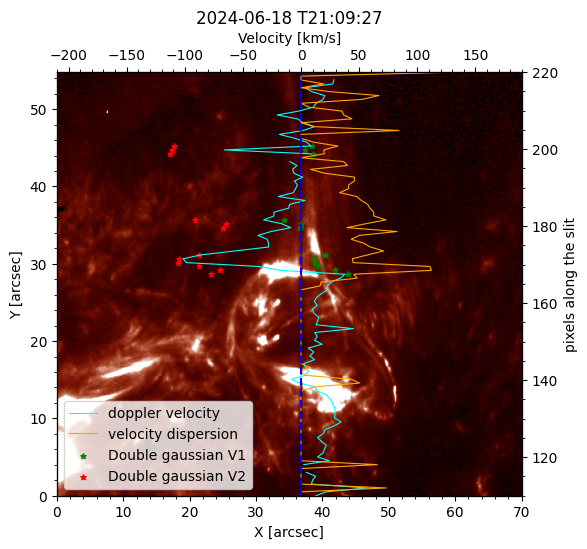

In [11]:
kk=399
i=kk*2+1
cnt=kk-398
fig,down_ax=plt.subplots(figsize=(6,5.5))
fig_data=all_sji_image[i][0][330:,:]
down_ax.imshow(fig_data,cmap='irissji1400',vmin=0,vmax=20,origin='lower',
        extent=[0,422*0.166,0,330*0.166])
down_ax.set_xlabel('X [arcsec]')
down_ax.set_ylabel('Y [arcsec]')
down_ax.set_aspect('auto')  # 或 'box' 而不是 'equal'

right_ax = down_ax.twinx()
right_ax.set_ylim(110, 220)
right_ax.minorticks_on()
right_ax.set_ylabel('pixels along the slit')
#创建第二根x轴
up_ax=down_ax.twiny()
#转化单位到角秒
y_vals=np.linspace(0,330*0.166,110)
up_ax.plot(doppler_vel[cnt,:],y_vals,color='cyan',linewidth=0.8,label='doppler velocity')
up_ax.plot(sigma_vel[cnt,:],y_vals,color='orange',linewidth=0.8,label='velocity dispersion')
up_ax.set_xlim(-210,190)

row=np.sum(vel_all[kk*2+1][:,4]==1)
double_scatter=np.zeros((row,3))
cnt=0
for i in range(110):
    if vel_all[kk*2+1][i,4]==1:
        double_scatter[cnt,0]=vel_all[kk*2+1][i,0]
        double_scatter[cnt,1]=vel_all[kk*2+1][i,2]
        double_scatter[cnt,2]=y_vals[i]
        cnt=cnt+1

up_ax.scatter(double_scatter[:,0],double_scatter[:,2],
            label='Double gaussian V1',s=15,
            color='green',marker='*')
up_ax.scatter(double_scatter[:,1],double_scatter[:,2],
            label='Double gaussian V2',s=15,
            color='red',marker='*')

#加标签
up_ax.set_xlabel('Velocity [km/s]')
up_ax.set_title(time_sequence[kk*2+1])
up_ax.legend(loc='lower left')
up_ax.minorticks_on()
up_ax.axvline(0,color='blue',linestyle='--')
plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\paper\fig\iris.pdf',format='pdf')
#保存

# plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\fig_with_double_vel\\'+str(2*kk+1)+'.png',dpi=300)
# plt.close()

OSError: [Errno 22] Invalid argument: 'D:\\Learning\\PHD1st\\magnetic_reconnecion\\data\\IRIS\\fig_with_double_vel\\\\815.png'

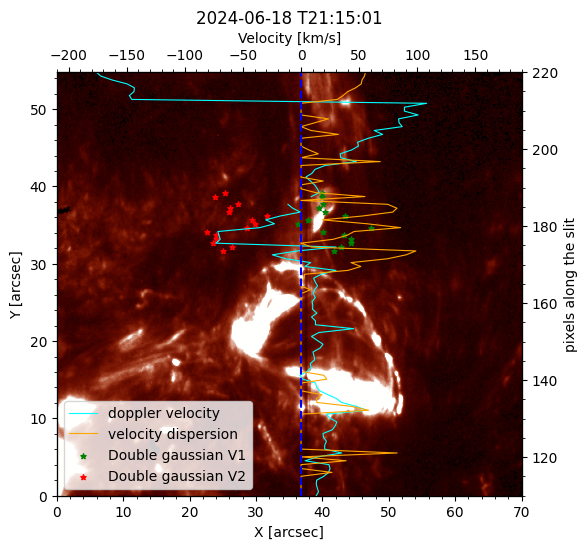

In [21]:
for kk in range(398,409):
    i=kk*2+1
    cnt=kk-398
    fig,down_ax=plt.subplots(figsize=(6,5.5))
    fig_data=all_sji_image[i][0][330:,:]
    down_ax.imshow(fig_data,cmap='irissji1400',vmin=0,vmax=20,origin='lower',
            extent=[0,422*0.166,0,330*0.166])
    down_ax.set_xlabel('X [arcsec]')
    down_ax.set_ylabel('Y [arcsec]')
    down_ax.set_aspect('auto')  # 或 'box' 而不是 'equal'
    
    right_ax = down_ax.twinx()
    right_ax.set_ylim(110, 220)
    right_ax.minorticks_on()
    right_ax.set_ylabel('pixels along the slit')
    #创建第二根x轴
    up_ax=down_ax.twiny()
    #转化单位到角秒
    y_vals=np.linspace(0,330*0.166,110)
    up_ax.plot(doppler_vel[cnt,:],y_vals,color='cyan',linewidth=0.8,label='doppler velocity')
    up_ax.plot(sigma_vel[cnt,:],y_vals,color='orange',linewidth=0.8,label='velocity dispersion')
    up_ax.set_xlim(-210,190)

    row=np.sum(vel_all[kk*2+1][:,4]==1)
    double_scatter=np.zeros((row,3))
    cnt=0
    for i in range(110):
        if vel_all[kk*2+1][i,4]==1:
            double_scatter[cnt,0]=vel_all[kk*2+1][i,0]
            double_scatter[cnt,1]=vel_all[kk*2+1][i,2]
            double_scatter[cnt,2]=y_vals[i]
            cnt=cnt+1

    up_ax.scatter(double_scatter[:,0],double_scatter[:,2],
                label='Double gaussian V1',s=15,
                color='green',marker='*')
    up_ax.scatter(double_scatter[:,1],double_scatter[:,2],
                label='Double gaussian V2',s=15,
                color='red',marker='*')

    #加标签
    up_ax.set_xlabel('Velocity [km/s]')
    up_ax.set_title(time_sequence[kk*2+1])
    up_ax.legend(loc='lower left')
    up_ax.minorticks_on()
    up_ax.axvline(0,color='blue',linestyle='--')

    #保存
    
    plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\fig_with_double_vel\\'+str(2*kk+1)+'.png',dpi=300)
    plt.close()

不放809的图  
813的181-185两个峰全在蓝侧